# Churn Dataset: Pooled Top-k Ranking Experiment

This notebook runs a ranking-based LazyFCA experiment on the churn dataset.

Main idea:
- keep the usual baseline thresholds only as a permissive pre-filter,
- for each query object, pool positive and negative classifiers together,
- rank the pooled classifiers by one chosen metric,
- keep only the Top-k classifiers from that pooled list,
- classify using only those Top-k classifiers,
- plot F1 as a function of k.

This differs from the threshold notebook because it does not sweep a metric threshold. Instead, it turns the explanation into a ranked list and truncates it directly.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MPLCONFIGDIR = ROOT / "experiments" / ".matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection
import tqdm.auto as tqdm

PLOTS_DIR = ROOT / "experiments" / "generated_plots" / "churn_topk_ranking_raw"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

from lazyfca.lazyfca import LazyFCA
from utils.estimate_quality import estimate_quality

In [2]:
import pandas
import sklearn.compose
import sklearn.model_selection
import sklearn.preprocessing

data = pandas.read_csv("../datasets/churn.csv")
data = data.drop(columns = ['customerID'])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

cols_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
data[cols_to_replace] = data[cols_to_replace].replace(['No phone service', 'No internet service'], 'No')

X = data.drop(columns = ["Churn"])
# y = data["Churn"].to_numpy()
y = (data["Churn"] == "Yes").to_numpy()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 42
)

numeric = [ "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))
ct = sklearn.compose.ColumnTransformer(
    transformers = [
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(dtype = 'bool'), categorical)
    ]
)
X_train = pandas.DataFrame(ct.fit_transform(X_train), columns = ct.get_feature_names_out())
X_test = pandas.DataFrame(ct.transform(X_test), columns = ct.get_feature_names_out())

categorical = [ feature for feature in ct.get_feature_names_out() if feature.startswith("categorical__") ]
X_train[categorical] = X_train[categorical].astype(bool)
X_test[categorical] = X_test[categorical].astype(bool)

y_train = pandas.Series(y_train)
y_test = pandas.Series(y_test)

## Baseline Threshold Params

`LazyFCA.Params(...)` is the threshold object used by LazyFCA.

Important detail:
- this object reuses the same dataclass as the metrics themselves,
- but when passed into `LazyFCA(...)`, its values are interpreted as lower/upper bounds for filtering classifiers.

Example:
- `supporters_covered=1` means keep only classifiers covering at least 1 supporter,
- `supporter_opposer_ratio=1.0` means keep only classifiers whose supporter/opposer ratio is at least 1.0.

Here we keep the same baseline thresholds as in the original rice notebook. They serve only as a permissive pre-filter before ranking.

In [3]:
baseline_classifier = LazyFCA(
    # pos_params=LazyFCA.Params(
    #     supporters_covered=5,
    #     supporter_opposer_ratio=1 / 2.75,
    # ),
    # neg_params=LazyFCA.Params(
    #     supporters_covered=10,
    #     supporter_opposer_ratio=4,
    # ),
    # pos_weight=1.0
    minimize_policy=LazyFCA.MinimizePolicy.BEFORE_FILTER
)
baseline_classifier.fit(X_train, y_train)

LazyFCA
  Status       : fitted
  Dataset      : 6328 samples (pos=1682, neg=4646)
  Features     : 36 binary, 3 numeric

  Filtering thresholds
  ------------------------------------
  pos_params    : (none)
  neg_params    : (none)
  pos_weight    : 1.0

  Ranking & top-k
  ------------------------------------
  pos_rank_by   : —
  neg_rank_by   : —
  rank_by       : —
  pos_top_k     : —
  neg_top_k     : —
  top_k         : —
  minimize_policy: MinimizePolicy.BEFORE_FILTER

In [4]:
expl = baseline_classifier.explain_sample(X_test.iloc[500])
expl.minimize(inplace=False)

Explanation
  Positive classifiers  : 741
  Negative classifiers  : 1087
  Total                 : 1828

  Top positive classifier
  ------------------------------------------
    Hypothesis    : 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; [12.0, 41.0]; [60.65, 83.75]; [743.3, 3273.55]
    Supporters    : 1682
    Opposers      : 4646

  Top negative classifier
  ------------------------------------------
    Hypothesis    : 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; [1.0, 12.0]; [20.15, 60.65]; [20.15, 743.3]
    Supporters    : 4646
    Opposers      : 1682

In [5]:
# Baseline threshold-only performance for reference.
baseline_y_pred = baseline_classifier.predict(X_test)
baseline_metrics = estimate_quality(baseline_y_pred, y_test)
baseline_metrics

100%|██████████| 704/704 [00:46<00:00, 15.00it/s]


{'Accuracy': 0.6846590909090909,
 'Precision': 0.23076923076923078,
 'Recall': 0.08021390374331551,
 'AUC-ROC': 0.4066446694732051,
 'F1-score': 0.11904761904761904,
 'True Positive': 15,
 'True Negative': 467,
 'False Positive': 50,
 'False Negative': 172,
 'True Negative Rate (Specificity)': 0.9032882011605415,
 'Negative Predictive Value': 0.730829420970266,
 'False Positive Rate': 0.09671179883945841,
 'False Discovery Rate': 0.7692307692307693}

## Precompute Explanations Once

Efficiency idea:
- explanations are the expensive part,
- threshold sweeps or top-k sweeps should not recompute them,
- we precompute them once using the baseline threshold filter,
- every metric/k experiment reuses those explanations.

In [6]:
explanations = baseline_classifier.explain(X_test)
len(explanations)

100%|██████████| 704/704 [01:08<00:00, 10.26it/s]


704

In [7]:
available_metrics = [
    "supporters_covered",
    "opposers_covered",
    "supporter_opposer_ratio",
    "support",
    "error_rate",
    "precision",
    "lift",
    "wracc",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "interval_tightness",
    "description_volume",
    "simplicity_prior",
    "query_binary_similarity",
    "query_numeric_similarity",
    "query_similarity",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "robustness",
    "delta_stability",
]

available_metrics

['supporters_covered',
 'opposers_covered',
 'supporter_opposer_ratio',
 'support',
 'error_rate',
 'precision',
 'lift',
 'wracc',
 'balanced_precision_proxy',
 'youdens_j',
 'matthews_correlation',
 'information_gain',
 'gini_gain',
 'log_odds_ratio',
 'chi_squared',
 'g_test',
 'interval_tightness',
 'description_volume',
 'simplicity_prior',
 'query_binary_similarity',
 'query_numeric_similarity',
 'query_similarity',
 'query_weighted_precision',
 'query_weighted_wracc',
 'stability',
 'robustness',
 'delta_stability']

## Efficient Pooled Top-k Evaluation

For each explanation and each metric:
1. put positive and negative classifiers in one pooled list,
2. score them by the chosen metric,
3. sort descending,
4. compute cumulative counts of positive and negative classifiers,
5. reuse those cumulative counts for all values of k.

This makes each metric experiment much faster than recomputing `predict()` for every k.

In [8]:
MINIMIZED_METRICS = {"opposers_covered", "error_rate", "description_volume"}

def metric_score(classifier, metric_name):
    value = classifier.get_metrics().get_metric(metric_name)
    return -value if metric_name in MINIMIZED_METRICS else value

def build_metric_cache(explanations, metric_name):
    cache = []
    for explanation in tqdm.tqdm(explanations, desc=f"Caching {metric_name}"):
        pooled = [
            *[(metric_score(clf, metric_name), 1) for clf in explanation.positive_classifiers],
            *[(metric_score(clf, metric_name), 0) for clf in explanation.negative_classifiers],
        ]

        if not pooled:
            cache.append({
                "total": 0,
                "cum_pos": np.array([], dtype=np.int32),
                "cum_neg": np.array([], dtype=np.int32),
            })
            continue

        pooled.sort(key=lambda item: item[0], reverse=True)
        labels = np.array([label for _, label in pooled], dtype=np.int32)
        cum_pos = np.cumsum(labels)
        cum_neg = np.cumsum(1 - labels)

        cache.append({
            "total": len(labels),
            "cum_pos": cum_pos,
            "cum_neg": cum_neg,
        })

    return cache

def predict_from_metric_cache(metric_cache, k, pos_weight=1.0):
    y_pred = np.zeros((len(metric_cache), 2), dtype=np.float64)

    for i, item in enumerate(metric_cache):
        total_available = item["total"]
        if total_available == 0 or k <= 0:
            y_pred[i] = [0.5, 0.5]
            continue

        take = min(k, total_available)
        pos_count = int(item["cum_pos"][take - 1])
        neg_count = int(item["cum_neg"][take - 1])

        weighted_pos = pos_weight * pos_count
        total = weighted_pos + neg_count
        if total == 0:
            y_pred[i] = [0.5, 0.5]
        else:
            y_pred[i] = [neg_count / total, weighted_pos / total]

    return y_pred

def evaluate_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_test, pos_weight=1.0):
    metric_cache = build_metric_cache(explanations, metric_name)
    rows = []

    for k in tqdm.tqdm(k_values, desc=f"Evaluating {metric_name}"):
        y_pred = predict_from_metric_cache(metric_cache, k, pos_weight=pos_weight)
        metrics = estimate_quality(y_pred, y_true)
        avg_kept = float(np.mean([min(k, item["total"]) for item in metric_cache]))
        rows.append({
            "k": int(k),
            "F1-score": metrics["F1-score"],
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "AUC-ROC": metrics["AUC-ROC"],
            "Average classifiers kept": avg_kept,
        })

    return pd.DataFrame(rows)

def plot_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_test, pos_weight=1.0):
    results = evaluate_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_true, pos_weight=pos_weight)
    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]
    plot_path = PLOTS_DIR / f"{metric_name}_topk_f1.png"

    plt.figure(figsize=(12, 6))
    plt.plot(results["k"], results["F1-score"], marker="o", linewidth=2)
    plt.axhline(baseline_metrics["F1-score"], color="red", linestyle="--", label="Baseline threshold-only")
    plt.scatter([best_row["k"]], [best_row["F1-score"]], color="green", s=80, zorder=3, label="Best Top-k")
    plt.xlabel("Top-k")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs pooled Top-k for metric: {metric_name}")
    plt.xlim(results["k"].max(), results["k"].min())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {plot_path}")
    print(f"Best k for {metric_name}: {int(best_row['k'])}")
    print(f"Best F1-score: {best_row['F1-score']:.6f}")
    print(f"Average classifiers kept: {best_row['Average classifiers kept']:.2f}")

    return results

In [9]:
# Build a top-heavy k-grid from the actual number of pooled classifiers.
# It always includes 1 and the maximum available number of classifiers.
# The grid is intentionally dense near the full classifier count.
max_total_classifiers = max(
    len(explanation.positive_classifiers) + len(explanation.negative_classifiers)
    for explanation in explanations
)

def build_top_heavy_k_grid(max_k, dense_tail=80, mid_points=50, low_points=30):
    if max_k <= 1:
        return np.array([1], dtype=int)

    values = {1, max_k}

    tail_start = max(1, max_k - dense_tail + 1)
    values.update(range(tail_start, max_k + 1))

    t = np.linspace(0.0, 1.0, mid_points)
    mid = np.rint(1 + (max_k - 1) * (t ** 2)).astype(int)
    values.update(mid.tolist())

    low = np.geomspace(1, max_k, low_points)
    low = np.rint(low).astype(int)
    values.update(low.tolist())

    return np.array(sorted(values, reverse=True), dtype=int)

k_values = build_top_heavy_k_grid(max_total_classifiers, dense_tail=80, mid_points=50, low_points=30)
print("Max pooled classifiers:", max_total_classifiers)
print("Number of k values:", len(k_values))
print("First 25 k values:", k_values[:25])
print("Last 25 k values:", k_values[-25:])
k_values

Max pooled classifiers: 2188
Number of k values: 152
First 25 k values: [2188 2187 2186 2185 2184 2183 2182 2181 2180 2179 2178 2177 2176 2175
 2174 2173 2172 2171 2170 2169 2168 2167 2166 2165 2164]
Last 25 k values: [118 111  92  91  75  70  59  53  46  41  34  31  24  18  16  14  11   9
   8   6   5   4   3   2   1]


array([2188, 2187, 2186, 2185, 2184, 2183, 2182, 2181, 2180, 2179, 2178,
       2177, 2176, 2175, 2174, 2173, 2172, 2171, 2170, 2169, 2168, 2167,
       2166, 2165, 2164, 2163, 2162, 2161, 2160, 2159, 2158, 2157, 2156,
       2155, 2154, 2153, 2152, 2151, 2150, 2149, 2148, 2147, 2146, 2145,
       2144, 2143, 2142, 2141, 2140, 2139, 2138, 2137, 2136, 2135, 2134,
       2133, 2132, 2131, 2130, 2129, 2128, 2127, 2126, 2125, 2124, 2123,
       2122, 2121, 2120, 2119, 2118, 2117, 2116, 2115, 2114, 2113, 2112,
       2111, 2110, 2109, 2100, 2013, 1928, 1846, 1764, 1685, 1678, 1608,
       1532, 1458, 1386, 1316, 1287, 1248, 1181, 1117, 1054,  993,  987,
        934,  876,  821,  767,  757,  715,  665,  617,  581,  570,  526,
        483,  446,  442,  403,  365,  342,  330,  296,  264,  262,  234,
        206,  201,  180,  155,  154,  132,  118,  111,   92,   91,   75,
         70,   59,   53,   46,   41,   34,   31,   24,   18,   16,   14,
         11,    9,    8,    6,    5,    4,    3,   

## Example: WRAcc

Caching wracc:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/152 [00:00<?, ?it/s]

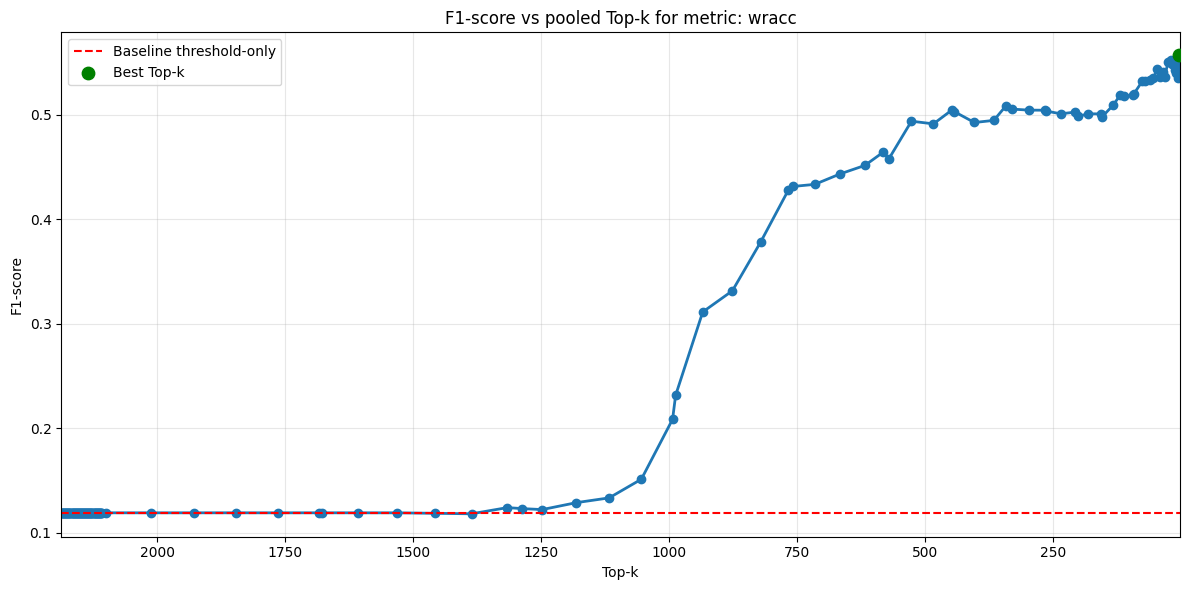

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\wracc_topk_f1.png
Best k for wracc: 2
Best F1-score: 0.556876
Average classifiers kept: 2.00


,k,F1-score,Accuracy,Precision,Recall,AUC-ROC,Average classifiers kept
0,2188,0.119048,0.684659,0.230769,0.080214,0.406645,1295.231534
1,2187,0.119048,0.684659,0.230769,0.080214,0.406655,1295.230114
2,2186,0.119048,0.684659,0.230769,0.080214,0.406665,1295.228693
3,2185,0.119048,0.684659,0.230769,0.080214,0.406676,1295.227273
4,2184,0.119048,0.684659,0.230769,0.080214,0.406655,1295.225852
...,...,...,...,...,...,...,...
147,5,0.535433,0.580966,0.379464,0.909091,0.741557,5.000000
148,4,0.554257,0.620739,0.402913,0.887701,0.731281,4.000000
149,3,0.537361,0.586648,0.382353,0.903743,0.728612,3.000000
150,2,0.556876,0.629261,0.407960,0.877005,0.717555,2.000000


In [10]:
wracc_results = plot_metric_topk("wracc", k_values)
wracc_results

## Run Any Metric

Examples:
- `plot_metric_topk("precision", k_values)`
- `plot_metric_topk("balanced_precision_proxy", k_values)`
- `plot_metric_topk("information_gain", k_values)`
- `plot_metric_topk("query_weighted_precision", k_values)`
- `plot_metric_topk("stability", k_values)`

Caching information_gain:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating information_gain:   0%|          | 0/152 [00:00<?, ?it/s]

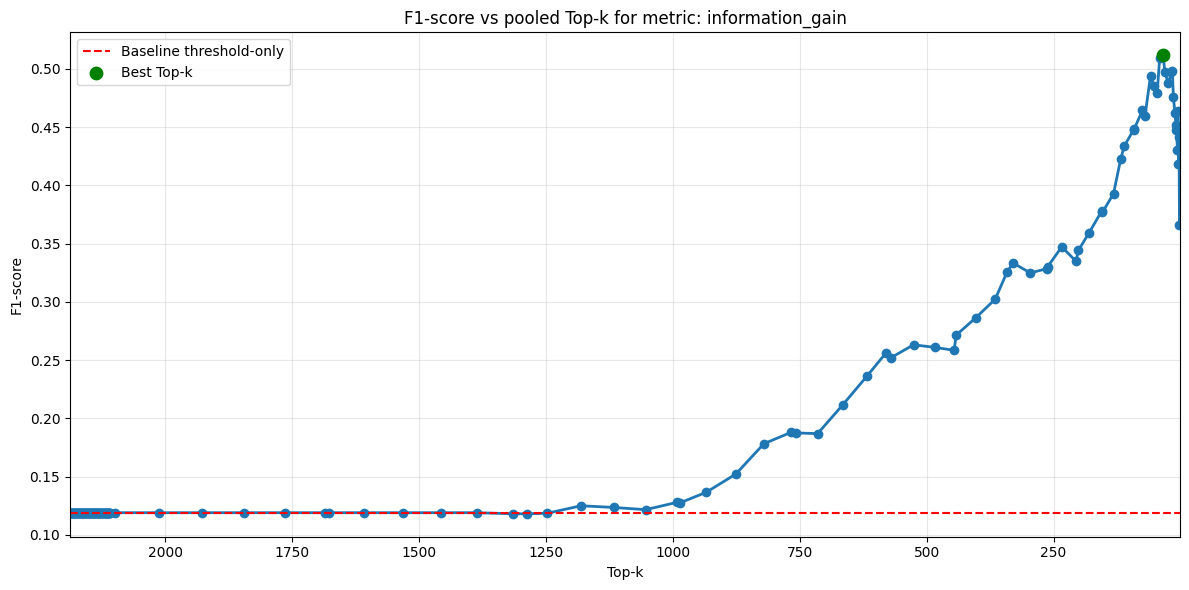

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\information_gain_topk_f1.png
Best k for information_gain: 34
Best F1-score: 0.511628
Average classifiers kept: 34.00


,k,F1-score,Accuracy,Precision,Recall,AUC-ROC,Average classifiers kept
0,2188,0.119048,0.684659,0.230769,0.080214,0.406645,1295.231534
1,2187,0.119048,0.684659,0.230769,0.080214,0.406655,1295.230114
2,2186,0.119048,0.684659,0.230769,0.080214,0.406634,1295.228693
3,2185,0.119048,0.684659,0.230769,0.080214,0.406634,1295.227273
4,2184,0.119048,0.684659,0.230769,0.080214,0.406634,1295.225852
...,...,...,...,...,...,...,...
147,5,0.463768,0.579545,0.350685,0.684492,0.655778,5.000000
148,4,0.418708,0.629261,0.358779,0.502674,0.646754,4.000000
149,3,0.441121,0.575284,0.339080,0.631016,0.636633,3.000000
150,2,0.365979,0.650568,0.353234,0.379679,0.621060,2.000000


In [11]:
metric_name = "information_gain"
results = plot_metric_topk(metric_name, k_values)
results

## Batch Run Over Several Metrics

This cell is optional. It can take time, but it is still much cheaper than recomputing explanations for every metric and every k.

In [12]:
metrics_to_try = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

summary_rows = []
for metric_name in metrics_to_try:
    results = evaluate_metric_topk(metric_name, k_values)
    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]
    summary_rows.append({
        "metric": metric_name,
        "best_k": int(best_row["k"]),
        "best_f1": best_row["F1-score"],
        "avg_classifiers_kept": best_row["Average classifiers kept"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="best_f1", ascending=False)
summary_df

Caching wracc:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/152 [00:00<?, ?it/s]

Caching lift:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/152 [00:00<?, ?it/s]

Caching balanced_precision_proxy:   0%|          | 0/704 [00:00<?, ?it/s]

...

Caching stability:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/152 [00:00<?, ?it/s]

Caching delta_stability:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/152 [00:00<?, ?it/s]

,metric,best_k,best_f1,avg_classifiers_kept
8,query_weighted_precision,31,0.575472,31.000000
0,wracc,2,0.556876,2.000000
2,balanced_precision_proxy,2,0.556876,2.000000
9,query_weighted_wracc,2,0.553691,2.000000
3,matthews_correlation,4,0.537994,4.000000
4,information_gain,34,0.511628,34.000000
7,g_test,34,0.511628,34.000000
5,gini_gain,34,0.498371,34.000000
6,chi_squared,34,0.498371,34.000000
1,lift,403,0.484241,390.100852



=== wracc ===


Caching wracc:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/152 [00:00<?, ?it/s]

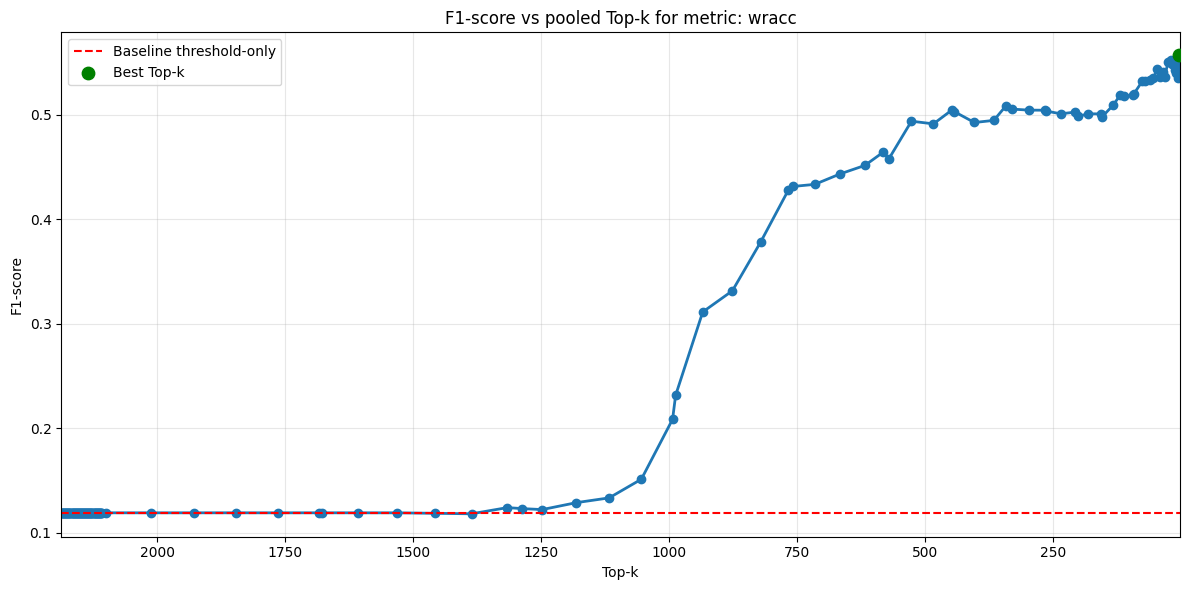

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\wracc_topk_f1.png
Best k for wracc: 2
Best F1-score: 0.556876
Average classifiers kept: 2.00

=== lift ===


Caching lift:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/152 [00:00<?, ?it/s]

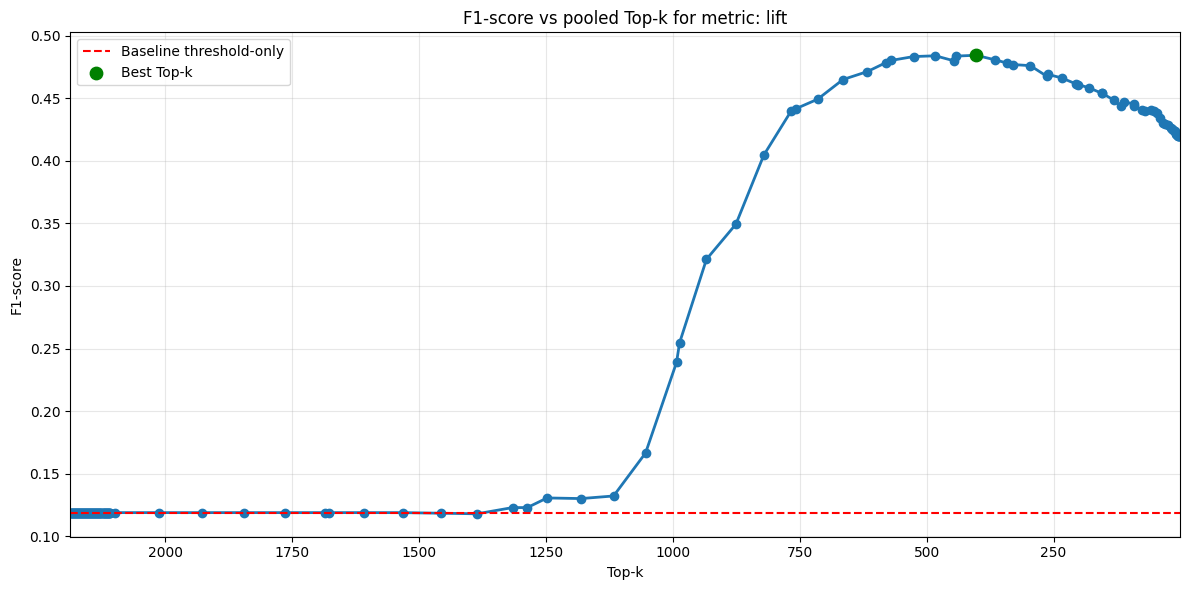

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\lift_topk_f1.png
Best k for lift: 403
Best F1-score: 0.484241
Average classifiers kept: 390.10

=== balanced_precision_proxy ===


Caching balanced_precision_proxy:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating balanced_precision_proxy:   0%|          | 0/152 [00:00<?, ?it/s]

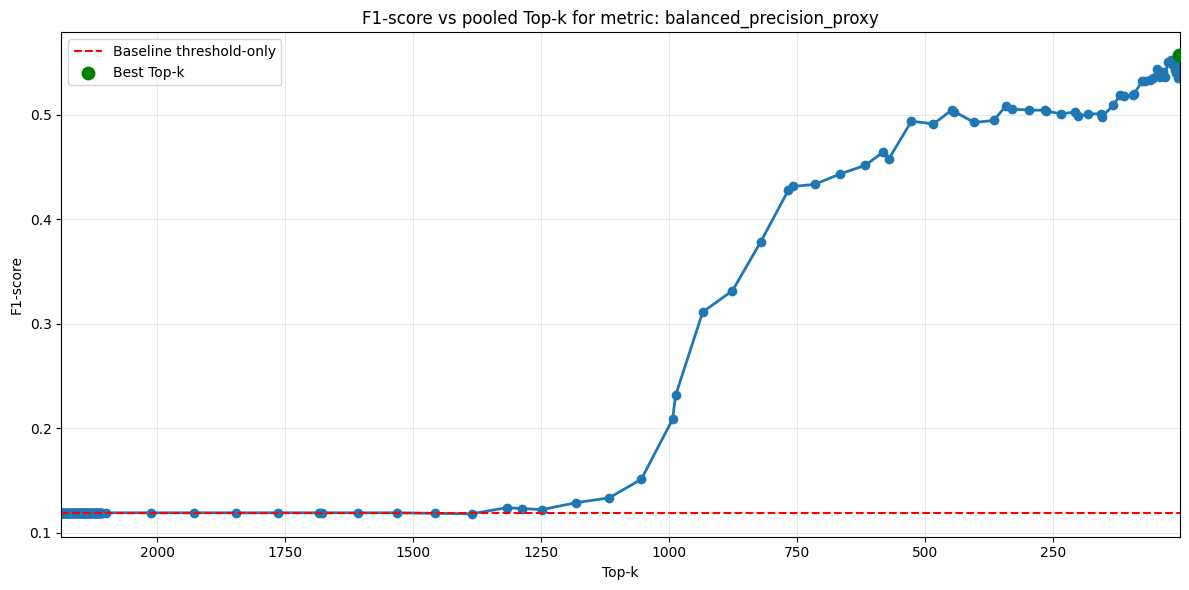

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\balanced_precision_proxy_topk_f1.png
Best k for balanced_precision_proxy: 2
Best F1-score: 0.556876
Average classifiers kept: 2.00

=== youdens_j ===


Caching youdens_j:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating youdens_j:   0%|          | 0/152 [00:00<?, ?it/s]

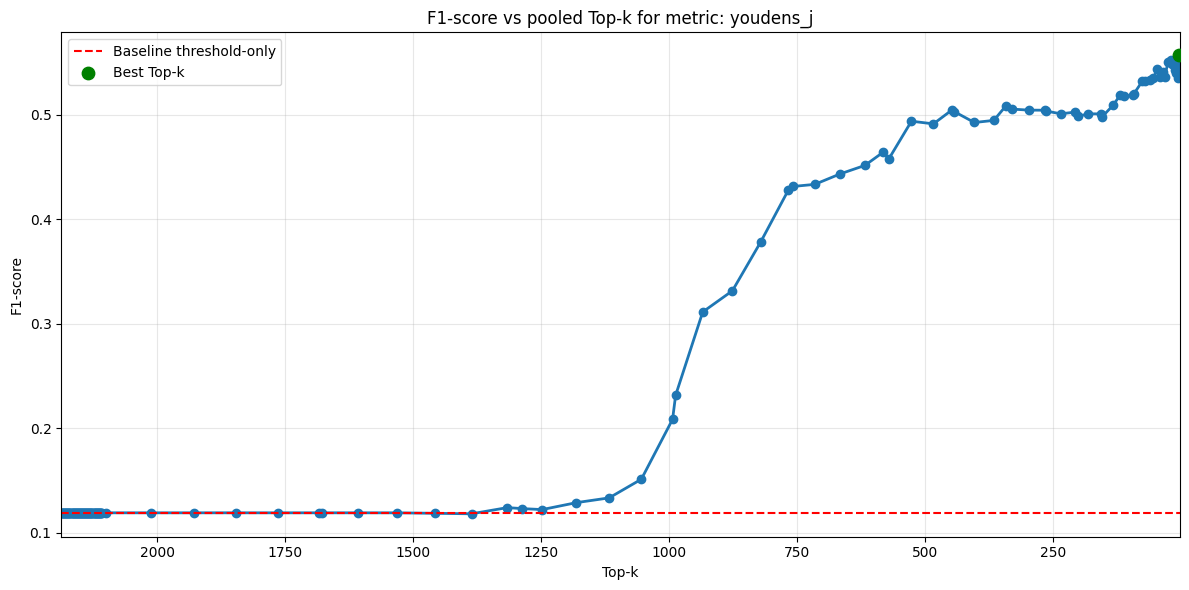

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\youdens_j_topk_f1.png
Best k for youdens_j: 2
Best F1-score: 0.556876
Average classifiers kept: 2.00

=== matthews_correlation ===


Caching matthews_correlation:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating matthews_correlation:   0%|          | 0/152 [00:00<?, ?it/s]

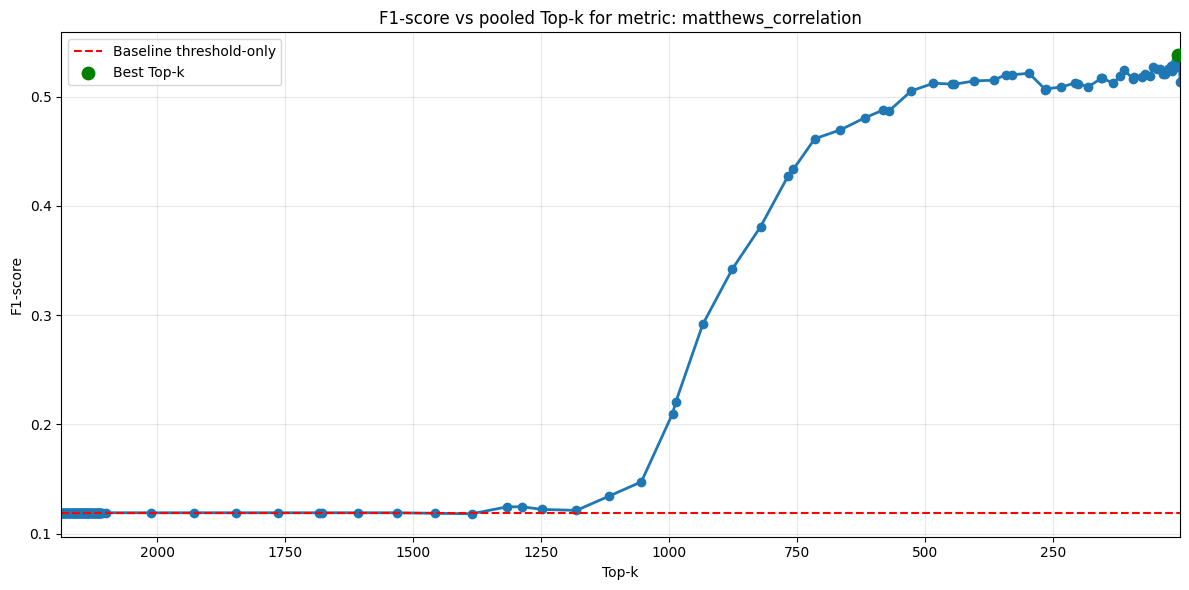

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\matthews_correlation_topk_f1.png
Best k for matthews_correlation: 4
Best F1-score: 0.537994
Average classifiers kept: 4.00

=== information_gain ===


Caching information_gain:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating information_gain:   0%|          | 0/152 [00:00<?, ?it/s]

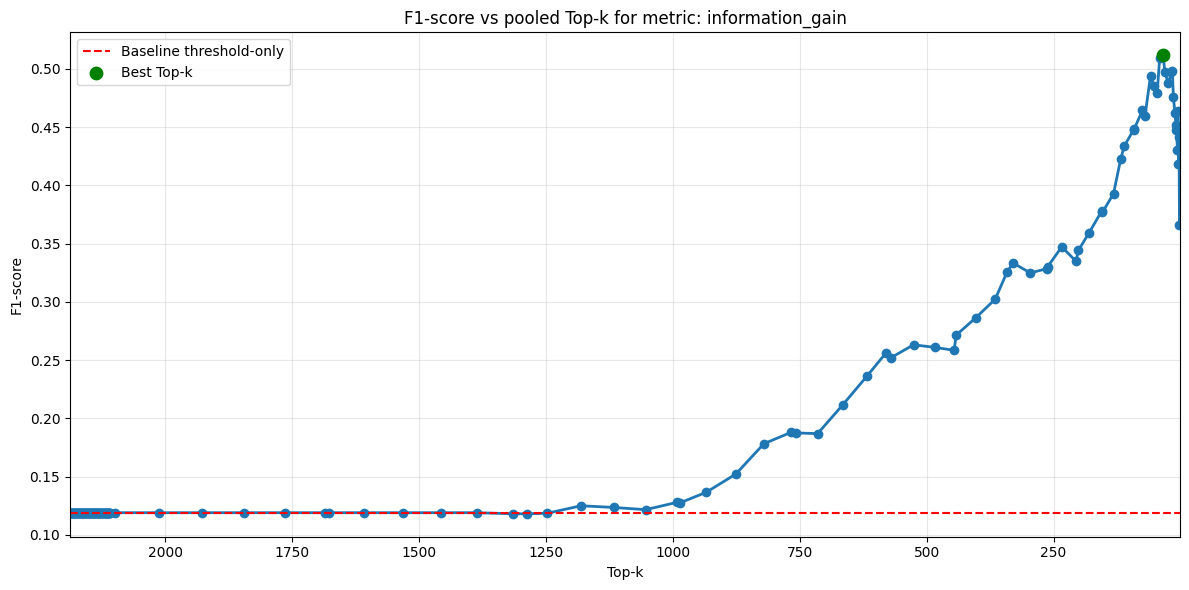

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\information_gain_topk_f1.png
Best k for information_gain: 34
Best F1-score: 0.511628
Average classifiers kept: 34.00

=== gini_gain ===


Caching gini_gain:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating gini_gain:   0%|          | 0/152 [00:00<?, ?it/s]

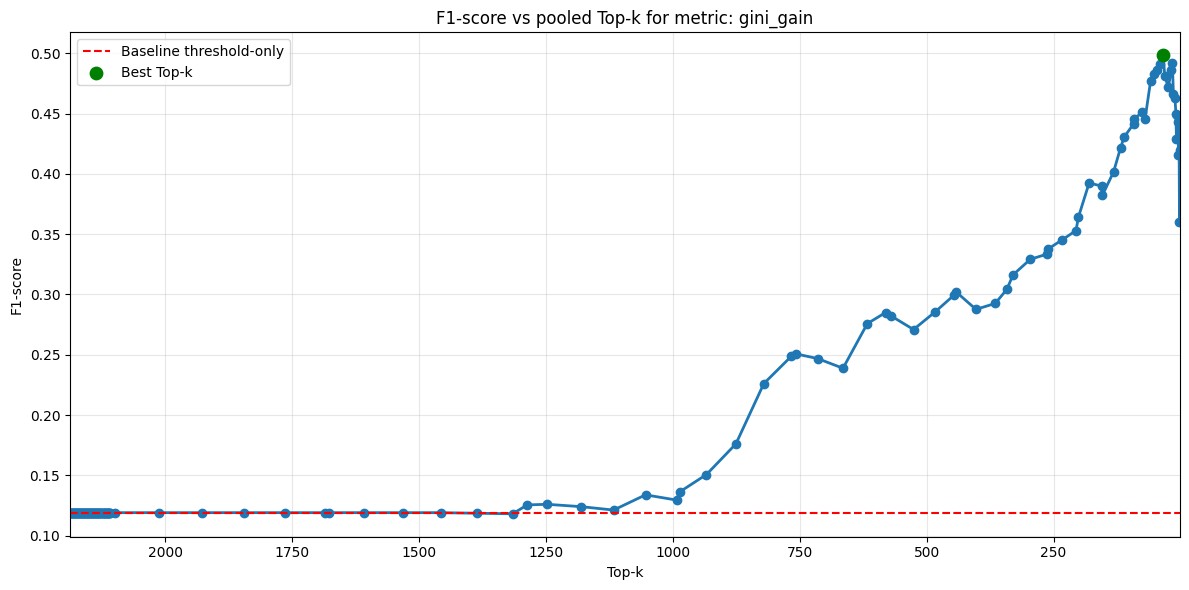

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\gini_gain_topk_f1.png
Best k for gini_gain: 34
Best F1-score: 0.498371
Average classifiers kept: 34.00

=== log_odds_ratio ===


Caching log_odds_ratio:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating log_odds_ratio:   0%|          | 0/152 [00:00<?, ?it/s]

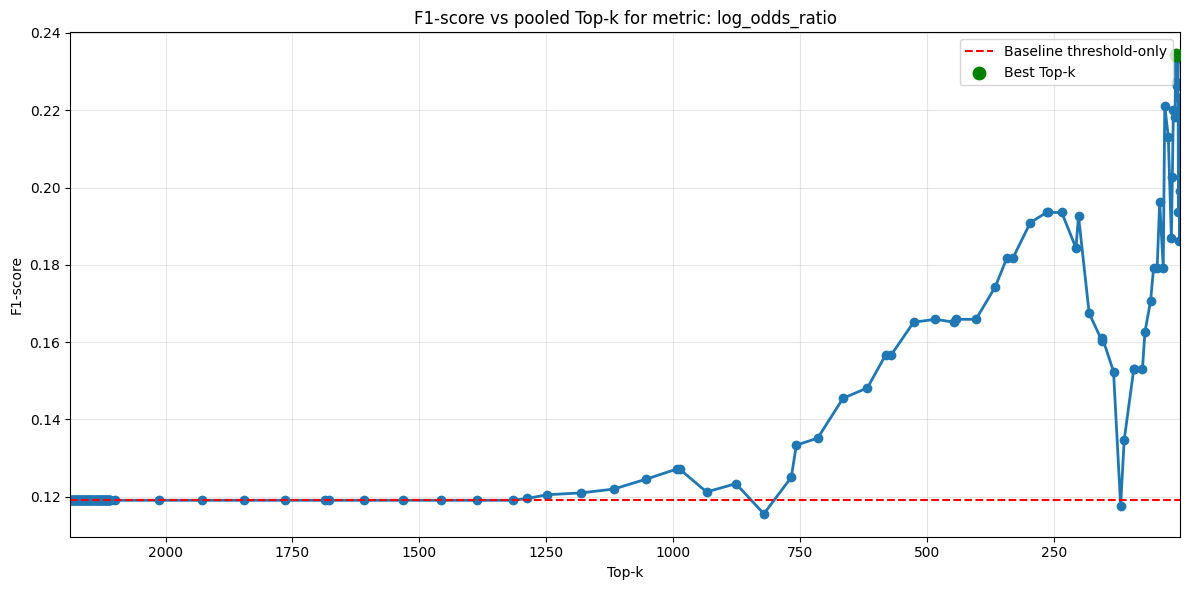

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\log_odds_ratio_topk_f1.png
Best k for log_odds_ratio: 9
Best F1-score: 0.234234
Average classifiers kept: 9.00

=== chi_squared ===


Caching chi_squared:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating chi_squared:   0%|          | 0/152 [00:00<?, ?it/s]

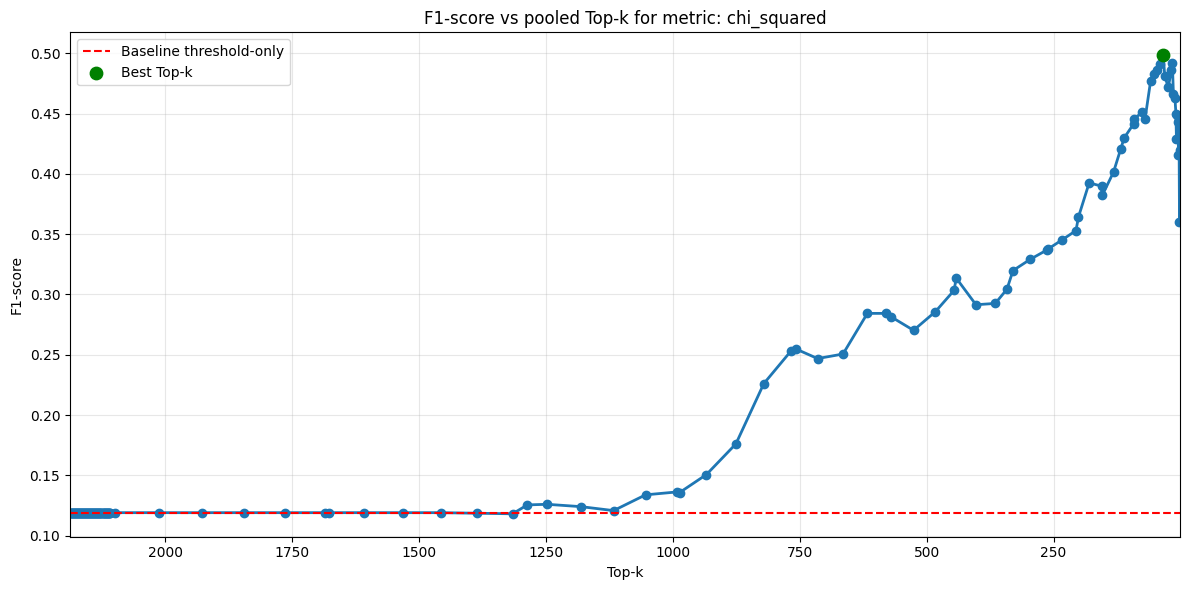

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\chi_squared_topk_f1.png
Best k for chi_squared: 34
Best F1-score: 0.498371
Average classifiers kept: 34.00

=== g_test ===


Caching g_test:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating g_test:   0%|          | 0/152 [00:00<?, ?it/s]

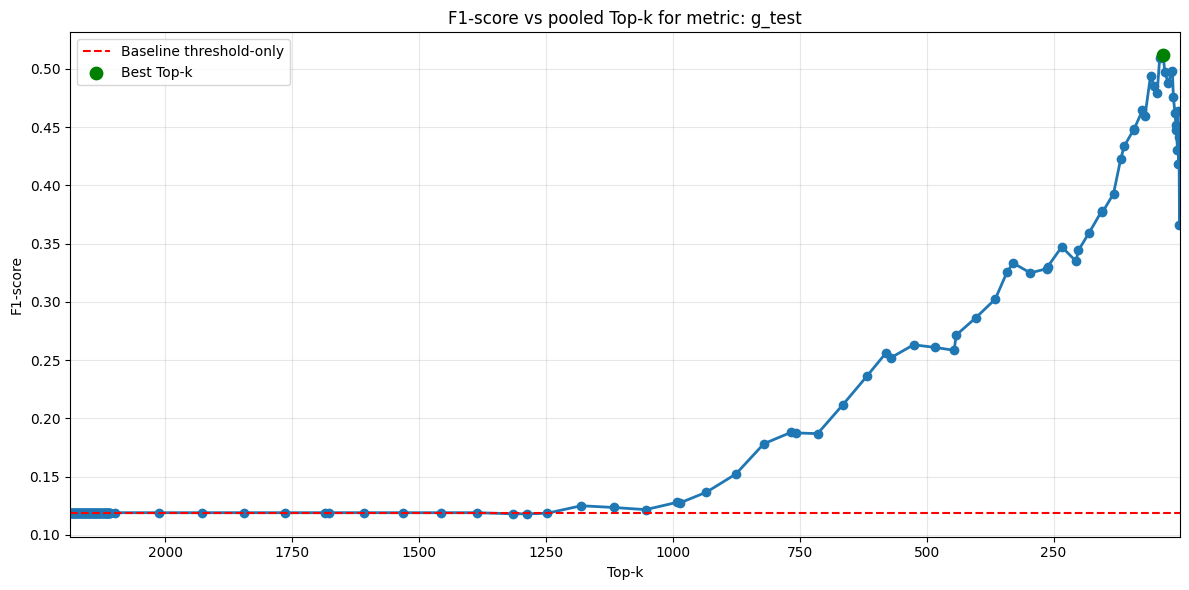

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\g_test_topk_f1.png
Best k for g_test: 34
Best F1-score: 0.511628
Average classifiers kept: 34.00

=== query_weighted_precision ===


Caching query_weighted_precision:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating query_weighted_precision:   0%|          | 0/152 [00:00<?, ?it/s]

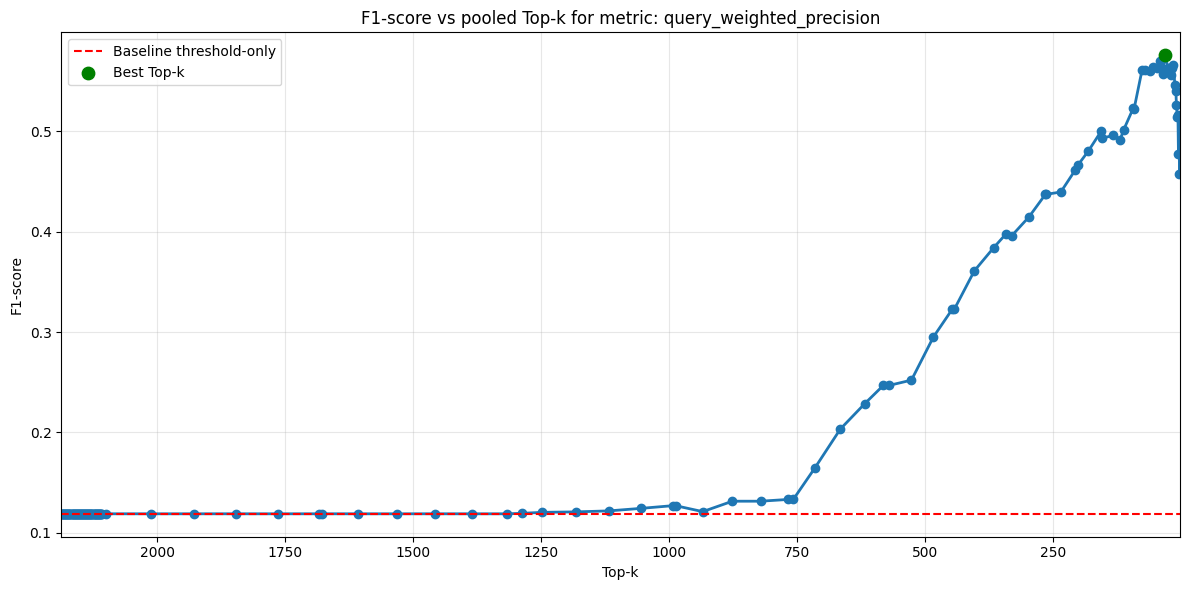

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\query_weighted_precision_topk_f1.png
Best k for query_weighted_precision: 31
Best F1-score: 0.575472
Average classifiers kept: 31.00

=== query_weighted_wracc ===


Caching query_weighted_wracc:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating query_weighted_wracc:   0%|          | 0/152 [00:00<?, ?it/s]

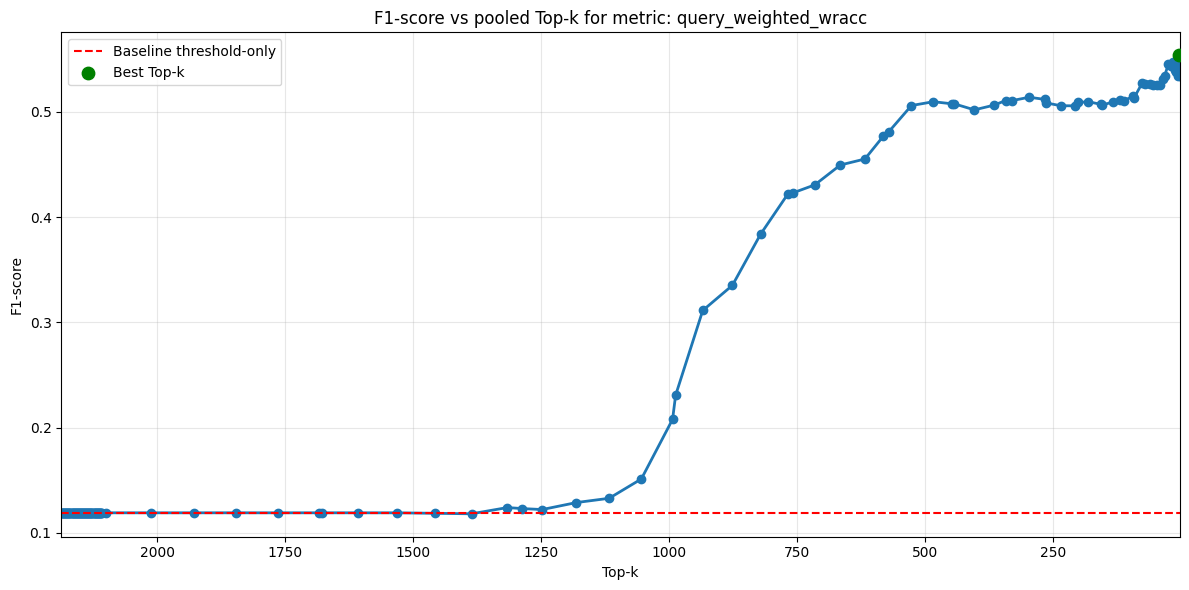

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\query_weighted_wracc_topk_f1.png
Best k for query_weighted_wracc: 2
Best F1-score: 0.553691
Average classifiers kept: 2.00

=== stability ===


Caching stability:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/152 [00:00<?, ?it/s]

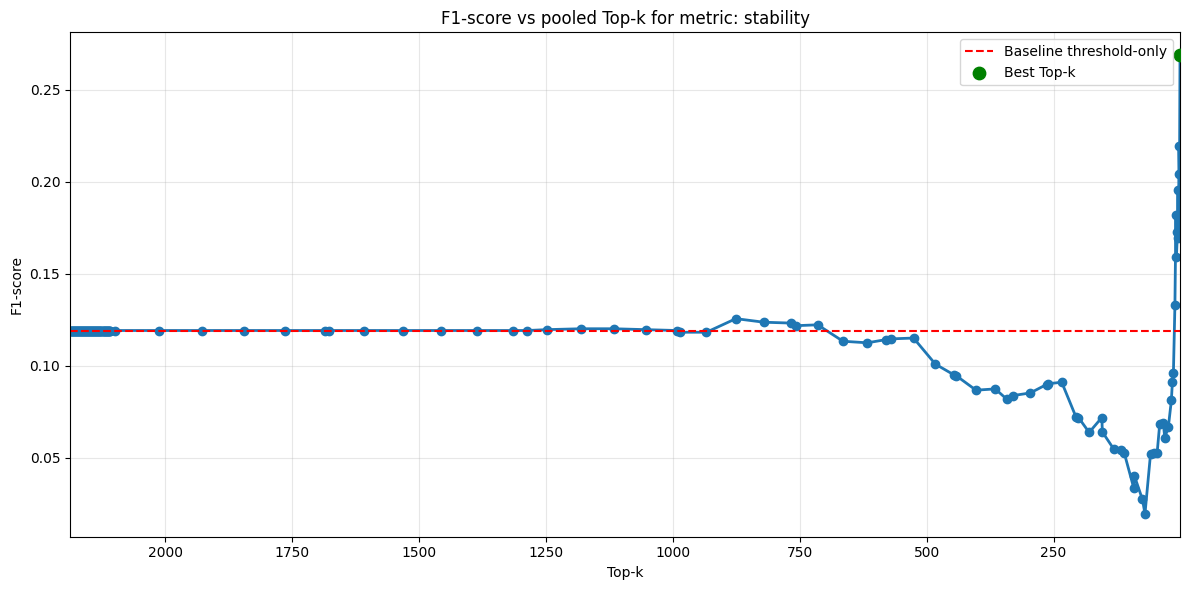

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\stability_topk_f1.png
Best k for stability: 1
Best F1-score: 0.268657
Average classifiers kept: 1.00

=== delta_stability ===


Caching delta_stability:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/152 [00:00<?, ?it/s]

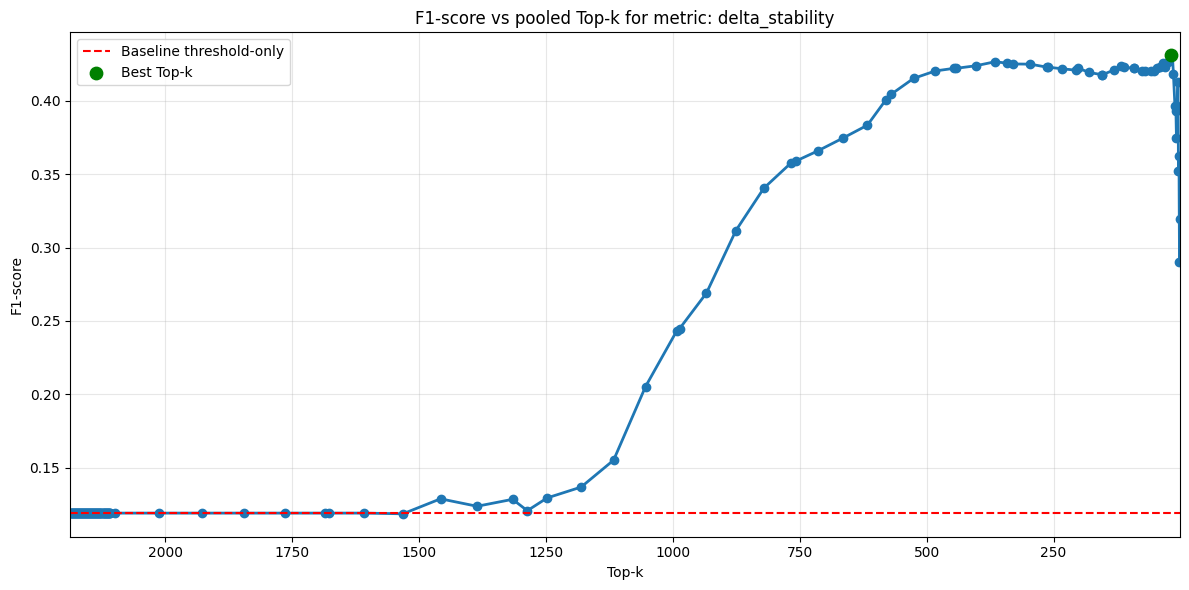

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\delta_stability_topk_f1.png
Best k for delta_stability: 18
Best F1-score: 0.431095
Average classifiers kept: 18.00


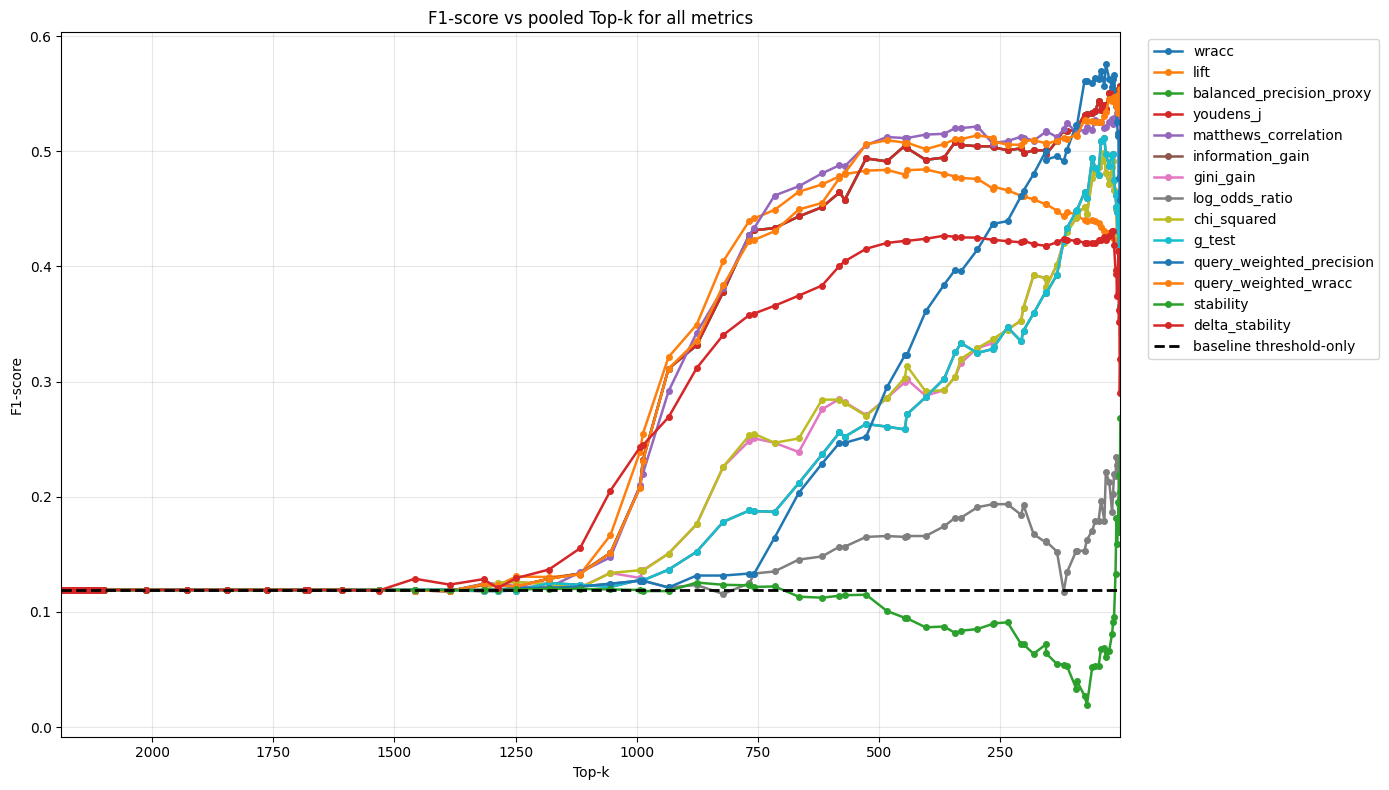


Saved combined plot to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\all_metrics_topk_f1.png
Saved summary CSV to: D:\OSDA-LazyFCA\experiments\generated_plots\churn_topk_ranking_raw\topk_summary.csv


,metric,best_k,best_f1,avg_classifiers_kept
10,query_weighted_precision,31,0.575472,31.000000
0,wracc,2,0.556876,2.000000
2,balanced_precision_proxy,2,0.556876,2.000000
3,youdens_j,2,0.556876,2.000000
11,query_weighted_wracc,2,0.553691,2.000000
4,matthews_correlation,4,0.537994,4.000000
5,information_gain,34,0.511628,34.000000
9,g_test,34,0.511628,34.000000
6,gini_gain,34,0.498371,34.000000
8,chi_squared,34,0.498371,34.000000


In [13]:
metrics_to_plot = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

all_results = {}
summary_rows = []

for metric_name in metrics_to_plot:
    print(f"\n=== {metric_name} ===")
    results = plot_metric_topk(metric_name, k_values)
    all_results[metric_name] = results.copy()

    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]

    summary_rows.append({
        "metric": metric_name,
        "best_k": int(best_row["k"]),
        "best_f1": float(best_row["F1-score"]),
        "avg_classifiers_kept": float(best_row["Average classifiers kept"]),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="best_f1", ascending=False)
summary_df.to_csv(PLOTS_DIR / "topk_summary.csv", index=False)

# Combined plot with all metrics together
plt.figure(figsize=(14, 8))
for metric_name, results in all_results.items():
    plt.plot(results["k"], results["F1-score"], marker="o", linewidth=1.8, markersize=4, label=metric_name)

plt.axhline(
    baseline_metrics["F1-score"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="baseline threshold-only"
)

plt.xlabel("Top-k")
plt.ylabel("F1-score")
plt.title("F1-score vs pooled Top-k for all metrics")
plt.xlim(max(k_values), min(k_values))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

combined_plot_path = PLOTS_DIR / "all_metrics_topk_f1.png"
plt.savefig(combined_plot_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"\nSaved combined plot to: {combined_plot_path}")
print(f"Saved summary CSV to: {PLOTS_DIR / 'topk_summary.csv'}")

summary_df


In [14]:
metric_name = "query_weighted_precision"
k_value = 20

results = evaluate_metric_topk(metric_name, np.array([k_value]))
row = results.iloc[0]

print(f"Metric: {metric_name}")
print(f"Top-k: {int(row['k'])}")
print(f"F1-score: {row['F1-score']:.6f}")
print(f"Accuracy: {row['Accuracy']:.6f}")
print(f"Precision: {row['Precision']:.6f}")
print(f"Recall: {row['Recall']:.6f}")
print(f"AUC-ROC: {row['AUC-ROC']:.6f}")
print(f"Average classifiers kept: {row['Average classifiers kept']:.2f}")


Caching query_weighted_precision:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating query_weighted_precision:   0%|          | 0/1 [00:00<?, ?it/s]

Metric: query_weighted_precision
Top-k: 20
F1-score: 0.566586
Accuracy: 0.745739
Precision: 0.517699
Recall: 0.625668
AUC-ROC: 0.776575
Average classifiers kept: 20.00


In [15]:
def rank_metrics_by_f1_retention(
    metrics_to_check,
    allowed_drop_percent=5.0,
    k_values=k_values,
    baseline_f1=None,
    explanations=explanations,
    y_true=y_test,
    pos_weight=1.0,
):
    """
    Rank metrics by how aggressively they can prune while keeping F1 within
    an allowed percentage drop from baseline.

    Rule:
    - Let baseline F1 be F_base.
    - Allowed minimum F1 is:
          F_min = F_base * (1 - allowed_drop_percent / 100)
    - We scan k_values in descending order (from large k to small k).
    - As soon as F1 drops below F_min, we stop.
    - The selected k is the last valid k before the break.

    Output:
    - A dataframe ordered best -> worst.
    - Best means smaller retained k first.
    - Ties are broken by higher retained F1.
    """

    if baseline_f1 is None:
        baseline_f1 = float(baseline_metrics["F1-score"])

    if allowed_drop_percent < 0:
        raise ValueError("allowed_drop_percent must be non-negative")

    f1_threshold = baseline_f1 * (1.0 - allowed_drop_percent / 100.0)

    rows = []

    for metric_name in metrics_to_check:
        results = evaluate_metric_topk(
            metric_name=metric_name,
            k_values=k_values,
            explanations=explanations,
            y_true=y_true,
            pos_weight=pos_weight,
        ).sort_values("k", ascending=False).reset_index(drop=True)

        last_valid_row = None
        broke = False

        for _, row in results.iterrows():
            if row["F1-score"] >= f1_threshold:
                last_valid_row = row
            else:
                broke = True
                break

        if last_valid_row is None:
            rows.append({
                "metric": metric_name,
                "selected_k": np.nan,
                "selected_f1": np.nan,
                "baseline_f1": baseline_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": np.nan,
                "status": "never_satisfies_rule",
            })
        else:
            rows.append({
                "metric": metric_name,
                "selected_k": int(last_valid_row["k"]),
                "selected_f1": float(last_valid_row["F1-score"]),
                "baseline_f1": baseline_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": float(last_valid_row["Average classifiers kept"]),
                "status": "break_found" if broke else "all_k_valid",
            })

    summary = pd.DataFrame(rows)

    # Best -> worst:
    # 1) metrics that satisfy the rule
    # 2) among them, smaller selected_k is better
    # 3) if tied, higher F1 is better
    # 4) metrics that never satisfy the rule go last
    summary["valid"] = summary["selected_k"].notna()

    summary = summary.sort_values(
        by=["valid", "selected_k", "selected_f1"],
        ascending=[False, True, False],
        na_position="last",
    ).reset_index(drop=True)

    return summary.drop(columns=["valid"])


In [16]:
metrics_to_check = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

rank_metrics_by_f1_retention(
    metrics_to_check=metrics_to_check,
    allowed_drop_percent=5.0,
)


Caching wracc:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/152 [00:00<?, ?it/s]

Caching lift:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/152 [00:00<?, ?it/s]

Caching balanced_precision_proxy:   0%|          | 0/704 [00:00<?, ?it/s]

...

Caching stability:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/152 [00:00<?, ?it/s]

Caching delta_stability:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/152 [00:00<?, ?it/s]

,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,wracc,1,0.540541,0.119048,0.113095,1.000000,all_k_valid
1,balanced_precision_proxy,1,0.540541,0.119048,0.113095,1.000000,all_k_valid
2,youdens_j,1,0.540541,0.119048,0.113095,1.000000,all_k_valid
3,query_weighted_wracc,1,0.533752,0.119048,0.113095,1.000000,all_k_valid
4,matthews_correlation,1,0.513399,0.119048,0.113095,1.000000,all_k_valid
5,query_weighted_precision,1,0.512821,0.119048,0.113095,1.000000,all_k_valid
6,information_gain,1,0.432836,0.119048,0.113095,1.000000,all_k_valid
7,g_test,1,0.432836,0.119048,0.113095,1.000000,all_k_valid
8,gini_gain,1,0.420168,0.119048,0.113095,1.000000,all_k_valid
9,chi_squared,1,0.420168,0.119048,0.113095,1.000000,all_k_valid


In [17]:
metrics_to_check = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

rank_metrics_by_f1_retention(
    metrics_to_check=metrics_to_check,
    allowed_drop_percent=1.0,
)


Caching wracc:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/152 [00:00<?, ?it/s]

Caching lift:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/152 [00:00<?, ?it/s]

Caching balanced_precision_proxy:   0%|          | 0/704 [00:00<?, ?it/s]

...

Caching stability:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/152 [00:00<?, ?it/s]

Caching delta_stability:   0%|          | 0/704 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/152 [00:00<?, ?it/s]

,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,wracc,1,0.540541,0.119048,0.117857,1.000000,all_k_valid
1,balanced_precision_proxy,1,0.540541,0.119048,0.117857,1.000000,all_k_valid
2,youdens_j,1,0.540541,0.119048,0.117857,1.000000,all_k_valid
3,query_weighted_wracc,1,0.533752,0.119048,0.117857,1.000000,all_k_valid
4,matthews_correlation,1,0.513399,0.119048,0.117857,1.000000,all_k_valid
5,query_weighted_precision,1,0.512821,0.119048,0.117857,1.000000,all_k_valid
6,information_gain,1,0.432836,0.119048,0.117857,1.000000,all_k_valid
7,g_test,1,0.432836,0.119048,0.117857,1.000000,all_k_valid
8,gini_gain,1,0.420168,0.119048,0.117857,1.000000,all_k_valid
9,chi_squared,1,0.420168,0.119048,0.117857,1.000000,all_k_valid
